Step-1: Import required library

In [1]:
import numpy as np #deals with a number
from astropy.io import fits #fits file i/o
import matplotlib.pyplot as plt #data visualization
from astropy.modeling.functional_models import Gaussian2D, Sersic2D #modeling of star + galaxy

Step-2: Create canvas: image size dan pizel size

In [2]:
# define image& pixel size
size=300
# create 2D meshgrid
x,y=np.meshgrid(np.arange(300),np.arange(300))
x.shape # my image pixel size in 300x300

(300, 300)

Step-3: Create star image with Gaussian 2D model

In [3]:
star= Gaussian2D(amplitude=5,x_mean=200,y_mean=200,x_stddev=5,y_stddev=5)
# create a star image from model
star_image=star(x,y)
star_image

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       ...,
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        1.76969651e-163, 3.58220401e-165, 6.96674729e-167],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        3.58220401e-165, 7.25106564e-167, 1.41020282e-168],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        6.96674729e-167, 1.41020282e-168, 2.74259272e-170]])

Step-4: Create a galaxy image with sersic model

In [9]:
galaxy=Sersic2D(amplitude=0.5,r_eff=50,n=5,x_0=100,y_0=150,theta=np.deg2rad(45),ellip=0.5)
galaxy

<Sersic2D(amplitude=0.5, r_eff=50., n=5., x_0=100., y_0=150., ellip=0.5, theta=0.78539816)>

In [10]:
# create galaxy image data as 2D
galaxy_image=galaxy(x,y)

Step-5: (Optional demo) Combine star + galaxy in one frame

**This combined image is only to visualize what a crowded field looks like.**
**Do NOT upload `mock_image.fits` to the classifier web app** — it contains
two objects in one frame, which the app cannot classify (it expects exactly
one star OR one galaxy per file). Use the separate `star_image.fits` /
`galaxy_image.fits` saved in Step-7 below instead.

In [11]:
mock_image=star_image + galaxy_image
mock_image

array([[0.02579938, 0.02584215, 0.02588052, ..., 0.00183986, 0.00182328,
        0.00180688],
       [0.02620717, 0.02625388, 0.02629609, ..., 0.00185551, 0.00183874,
        0.00182216],
       [0.02662138, 0.02667222, 0.02671845, ..., 0.00187132, 0.00185436,
        0.00183758],
       ...,
       [0.00498912, 0.00504389, 0.00509936, ..., 0.01227947, 0.01214091,
        0.01200371],
       [0.00492968, 0.00498357, 0.00503813, ..., 0.01224206, 0.01210496,
        0.01196917],
       [0.00487111, 0.00492413, 0.0049778 , ..., 0.01220359, 0.01206794,
        0.01193358]])

Step-6: Visualize mock images

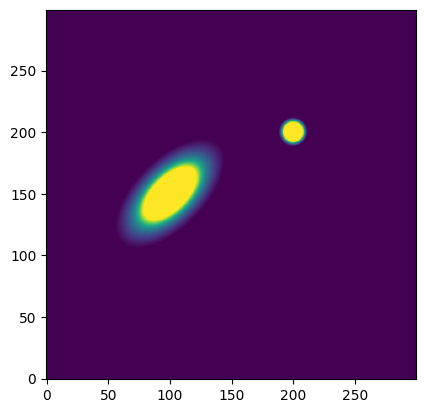

In [12]:
plt.imshow(mock_image,origin='lower',vmin=0.4,vmax=1.5)

Step-7: Save star and galaxy as SEPARATE FITS files

Each file must contain exactly **one** object — this is what the classifier
web app expects (just like a single telescope cutout). Upload
`star_image.fits` or `galaxy_image.fits`, not the combined one.

In [ ]:
fits.writeto('star_image.fits', star_image, overwrite=True)
fits.writeto('galaxy_image.fits', galaxy_image, overwrite=True)
print('Saved star_image.fits and galaxy_image.fits — upload these to the web app.')